# Exploratory Data Analysis (EDA).
Explore and understand the CheXpert_small and TBX11K datasets before training models.
#### Rationale:
1. Verify dataset contents, structure, and class distributions.
2. Detect potential imbalances or inconsistencies that may bias results.
3. Document image resolutions and formats to justify preprocessing choices.
4. Produce figures (class balance plots, histograms) to be discused in the report.

In [1]:
# Define dataset root paths (This notebook lives in notebooks/, so step one level up to reach the project root).
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()

# Define dataset paths relative to the project structure.
CHEXPERT_PATH = PROJECT_ROOT / "data" / "chexpert"
TBX11K_PATH   = PROJECT_ROOT / "data" / "tbx11k"

print('Project root:', PROJECT_ROOT)
print('CheXpert path exists:', CHEXPERT_PATH.exists())
print('TBX11K path exists:', TBX11K_PATH.exists())

Project root: /lab/px/msc-sept-24-ft-cohort-capstone-chrisanich
CheXpert path exists: True
TBX11K path exists: True


## 1. Dataset Overview.
Count images and inspect folder structure for CheXpert_small and TBX11K.
#### Rationale:
- Verify datasets were correctly downloaded and extracted.
- Check the amount of images in each dataset to assess balance.
- Document findings with numbers to support the Methods section of the report.

In [2]:
# Count the number of image files in each dataset directory.
# This ensures that data is complete before further analysis.

def count_images_in_folder(path: Path, exts=(".jpg", ".jpeg", ".png")):
    """Count image files recursively in a folder."""
    return sum(1 for f in path.rglob("*") if f.suffix.lower() in exts)

chexpert_count = count_images_in_folder(CHEXPERT_PATH)
tbx11k_count = count_images_in_folder(TBX11K_PATH)

print('Image counts:')
print(f'- CheXpert_small: {chexpert_count:,} images')
print(f'- TBX11B: {tbx11k_count:,} images')

Image counts:
- CheXpert_small: 223,649 images
- TBX11B: 12,279 images


## 2. Class Distribution (TBX11K).
Load the TBX11K dataset split list (`all_trainval.txt`) and infer labels from folder and filename conventions.
#### Rationale:
- TBX11K does not provide a ready-made CSV with labels.
- Instead, image labels are encoded in file paths (`sick/`, `tb/`, or filenames ending in `_1.png` for Tuberculosis (TB), others as Normal).
- Parsing the official split list ensures reproducibility and consistency with the dataset authors' organisation.
- Class counts are essential to detect imbalance before modeling training.

In [3]:
import pandas as pd

# Define load_tbx11k_from_list() function with a type hint "-> pd.DataFrame to tell the reader
# (and tools like linters or IDEs) that it expects a Path and return a Pandas Data Frame.
def load_tbx11k_from_list(list_file: Path) -> pd.DataFrame:
    """
    Load a TBX11K split list and assign class labels.

    Parameters
    ----------
    list_file : str or Path
        Path to a text file (e.g., all_train.txt, all_val.txt, all_test.txt, all_trainval.txt).
        Each line contains a relative path to an image file.

    Returns
    -------
    pd.DataFrame
        DataFrame with two columns:
        - 'Path': relative image path
        - "Class": assigned label ('TB' or 'Normal')
    """
    with open(list_file, "r") as f:
        paths = [line.strip() for line in f if line.strip()]

    records = []
    for p in paths:
        # Label assignment is based on TBX11K naming conventions.
        if p.startswith(("sick", "tb")) or p.endswith("_1.png"):
            label = "TB"
        else:
            label = "Normal"
        records.append({"Path": p, "Class": label})

    return pd.DataFrame(records)

# Load the combined training plus validation split.
tbx11k_df = load_tbx11k_from_list(TBX11K_PATH / "lists" / "all_trainval.txt")

# Summarise class distribution.
print("TBX11K class distribution (all_trainval split):")
print(tbx11k_df['Class'].value_counts().to_string())

TBX11K class distribution (all_trainval split):
Class
TB        4798
Normal    4178


## 3. Class Distribution (CheXpert_small).
Load CheXpert_small metadata  (`train.csv`) and derive class labels for Pneumonia vs non-Pneumonia.
#### Rationale:
- CheXpert provides multiple pathology labels: this study focuses on Pneumonia vs Normal.
- Sumarising class distribution ensures that the dataset is well understood before traning.
- Detecting imbalance is essential for designing evaluation estrategies.
- Provides reproducible evidence for dataset characteristics.
- CheXpert includes both frontal and lateral images; to avoid bias when combining with TBX11K (frontal only), this analysis retains only frontal views.

In [4]:
# Define load_chexpert_labels() function with a type hint "-> pd.DataFrame to tell the reader
# (and tools like linters or IDEs) that it expects a Path and return a Pandas Data Frame.
def load_chexpert_labels(csv_file: Path) -> pd.DataFrame:
    """
    Load CheXpert_small labels and reduce to Pneumonia vs Non-Pneumonia.

    Parameters
    ----------
    csv_file : Path
        Path to CheXpert's train.csv metadata file.

    Returns
    -------
    pd.DataFrame
    - 'Path': relative image path
    - 'Class': assigned label ('Pneumonia' or 'Non-Pneumonia')

    Notes
    -----
    CheXpert provides 14 pathology labels. For this project, only the 'Pneumonia'
    column is used. All images Pneumonia=1 are labelled 'Pneumonia';
    All others were grouped as Non-Pneumonia, irrespective of other co-existing pathologies.
    """
    df = pd.read_csv(csv_file)

    # Keep only image path and Pneumonia column.
    labels = df[["Path", "Pneumonia"]].copy()

    # Assign Normal vs Pneumonia class.
    labels["Class"] = labels["Pneumonia"].apply(lambda x: "Pneumonia" if x == 1 else "Non-Pneumonia")

    return labels

# Load labels from Chexpert train.csv.
chexpert_labels =load_chexpert_labels(CHEXPERT_PATH / "train.csv")

# Normalise paths by removing redundant dataset prefix.
# This is because the train.csv file includes the dataset’s original folder prefix, 
# the extracted dataset does not have that prefix in its folder structure.
chexpert_labels["Path"] = chexpert_labels["Path"].str.replace(
    "CheXpert-v1.0-small/", "", regex=False
)

# Keep only frontal images (excluse lateral views).
chexpert_labels = chexpert_labels[chexpert_labels["Path"].str.contains("frontal")]

# Summarise ditribution.
print("CheXpert_small class distribution (train split):")
print(chexpert_labels["Class"].value_counts().to_string())

CheXpert_small class distribution (train split):
Class
Non-Pneumonia    186352
Pneumonia          4675


## 4. Class Distribution (Separate Data Summaries)
Summarise the class counts for CheXpert_small and TBX11K separately.
#### Rationale:
- Provide a transparent description of how many samples exist in each dataset.
- Highlight class imbalance within each source before combining them.
- Document clearly what raw material is available for later modelling.
- Ensure reproducibility by showing dataset-specific counts before any merging.

In [5]:
# Compute class distribution for CheXpert_small (already loaded).
chexpert_counts = chexpert_labels["Class"].value_counts()

# Compute class distrubution for TBX11K (already loaded).
tbx11k_counts = tbx11k_df["Class"].value_counts()

# Combine into one summary DataFrame.
summary_df = pd.DataFrame({
    "CheXpert_small": chexpert_counts,
    "TBX11K": tbx11k_counts
}).fillna(0).astype(int) # Replace NaN with 0 to make the table clean and clear.

print("Class distributions per dataset:")
print(summary_df)

Class distributions per dataset:
               CheXpert_small  TBX11K
Class                                
Non-Pneumonia          186352       0
Normal                      0    4178
Pneumonia                4675       0
TB                          0    4798


#### Insights:
- Each dataset keeps its own classes.
- Missing classes are shown as `0` rather than `NaN`.
- It is possible to infer that **CheXpert** contributes `Pneumonia` and `Non-Pneumonia`, while **TBX11K** contributes `TB` and `Normal`.

## 5a. Class Distribution (Unified 3-Class Task).
Define that the final 3-class dataset used this project: Normal, Pneumonia, and Tuberculosis (TB).
#### Rationale:
- CheXpert_small provides `Pneumonia` cases.
- TBX11K provides `Normal` and `TB` cases.
- Combining these sources yield a clean 3-class problem without ambiguous categories.
- This step formalises the dataset definition used in all subsequent modelling experiments.

In [6]:
# Extract Pneumonia counts from CheXpert.
pneumonia_count = chexpert_labels["Class"].value_counts().get("Pneumonia", 0)

# Extract Normal and TB counts from TBX11K.
tb_counts = tbx11k_df["Class"].value_counts()
normal_count = tb_counts.get("Normal", 0)
tb_count     = tb_counts.get("TB", 0)

# Build unified 3-class summary.
unified_summary = pd.DataFrame({
    "Class": ["Normal", "Pneumonia", "TB"],
    "Dataset": ["TBX11K", "CheXpert", "TBX11K"],
    "Count" : [normal_count, pneumonia_count, tb_count]
})

print("Unified 3-class dataset summary:")
print(unified_summary.to_string(index=False))

Unified 3-class dataset summary:
    Class  Dataset  Count
   Normal   TBX11K   4178
Pneumonia CheXpert   4675
       TB   TBX11K   4798


## 5b. Class Distribution (Unified 3-Class Plot).
Visualise the unified dataset distribution across `Normal`, `Pneumonia`, and `TB`.
#### Rationale:
- Highlight the relative sizes of the three target classes.
- Provide a clear figure suitable for inclusion in the report.
- Make visible the imbalance between classes, guiding evaluation choices.
- Document the exact dataset composition used for model training.

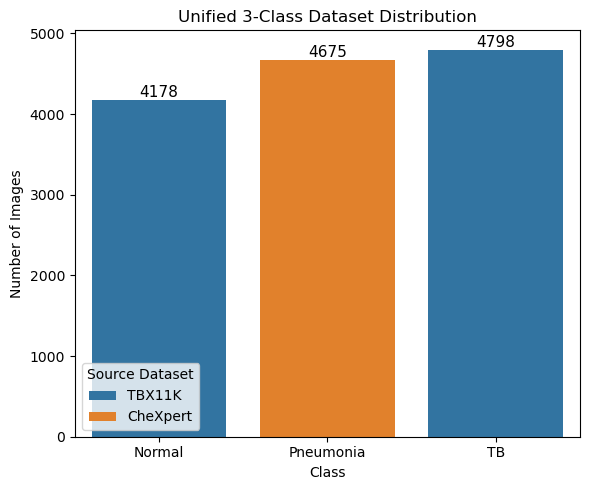

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6, 5))
ax = sns.barplot(
    x=unified_summary["Class"],
    y=unified_summary["Count"],
    hue=unified_summary["Dataset"],
    dodge=False
)

plt.title("Unified 3-Class Dataset Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.legend(title="Source Dataset")

# Annotate bars, ignoring the zero-height ones
for p in ax.patches:
    h = p.get_height()
    if h == 0:
        continue
    ax.text(p.get_x() + p.get_width()/2, h, f"{int(h)}",
            ha="center", va="bottom", fontsize=11)

plt.tight_layout()
plt.show()

## 6. Image Properties.
Inspect file formats, image modes (grayscale vs RGB), and resolutions for CheXpert_small and TBX11K.  
#### Rationale:
- Create a function `scan_images` to read a sample of up to 2000 files and count formats, modes, and resolutions.  
- Apply the scan to the **CheXpert_small** train split as a whole to confirm image consistency.  
- Check each **TBX11K** subfolder (`health`, `sick`, `tb`, `extra`, `test`) separately to capture differences between groups.  
- Base preprocessing decisions (resizing to 320×320 and converting modes if needed) on the observed dataset properties.  

In [8]:
from pathlib import Path
from PIL import Image
import os
from collections import Counter

def scan_images(root_path, max_samples=2000):
    """
    Scan a folder of images and count:
      - Formats (JPEG, PNG…)
      - Modes (L=grayscale, RGB…)
      - Resolutions (width×height)
    Stops early if max_samples is reached.
    """
    # Counters for image properties.
    formats, modes, resolutions = Counter(), Counter(), Counter()
    count = 0

    # Walk through all files under the root path.
    for dirpath, _, filenames in os.walk(root_path):
        for fname in filenames:
            # Only consider image files
            if fname.lower().endswith((".png", ".jpg", ".jpeg")):
                try:
                    # Open image to check its properties
                    with Image.open(os.path.join(dirpath, fname)) as img:
                        formats[img.format] += 1
                        modes[img.mode] += 1
                        resolutions[img.size] += 1
                except:
                    continue  # skip unreadable/corrupt images.

                count += 1
                # Stop if we already inspected enough samples.
                if count >= max_samples:
                    return formats, modes, resolutions, count

    return formats, modes, resolutions, count

# ---- CheXpert ----
# Inspect up to 2000 images from CheXpert train split.
f, m, r, c = scan_images(CHEXPERT_PATH / "train", max_samples=2000)
print("\n--- CheXpert_small (train) ---")
print(f"Scanned: {c} images")
print("Formats:", dict(f.most_common(5)))
print("Modes:", dict(m.most_common(5)))
print("Resolutions:", {f"{w}×{h}": n for (w,h), n in r.most_common(5)})

# ---- TBX11K ----
# Inspect each subfolder in TBX11K (health, sick, tb, etc).
print("\n--- TBX11K (by folder) ---")
for sub in sorted((TBX11K_PATH / "imgs").iterdir()):
    if sub.is_dir():
        f, m, r, c = scan_images(sub, max_samples=2000)
        print(f"\nFolder: {sub.name} (scanned {c} images)")
        print("Formats:", dict(f.most_common(5)))
        print("Modes:", dict(m.most_common(5)))
        print("Resolutions:", {f"{w}×{h}": n for (w,h), n in r.most_common(5)})


--- CheXpert_small (train) ---
Scanned: 2000 images
Formats: {'JPEG': 2000}
Modes: {'L': 2000}
Resolutions: {'390×320': 1165, '320×320': 228, '389×320': 195, '320×390': 59, '320×369': 40}

--- TBX11K (by folder) ---

Folder: extra (scanned 576 images)
Formats: {'PNG': 472, 'JPEG': 104}
Modes: {'RGB': 576}
Resolutions: {'512×512': 576}

Folder: health (scanned 2000 images)
Formats: {'PNG': 2000}
Modes: {'RGB': 2000}
Resolutions: {'512×512': 2000}

Folder: sick (scanned 2000 images)
Formats: {'PNG': 2000}
Modes: {'RGB': 2000}
Resolutions: {'512×512': 2000}

Folder: tb (scanned 800 images)
Formats: {'PNG': 800}
Modes: {'RGB': 800}
Resolutions: {'512×512': 800}

Folder: test (scanned 2000 images)
Formats: {'PNG': 2000}
Modes: {'RGB': 2000}
Resolutions: {'512×512': 2000}


## 7. Display Sample Images.
Display representative sample images from each target class: `Normal`, `Pneumonia`, and `TB`.
#### Rationale:
- Provide a visual impression of the datasets for the reader.
- Confirm that labels correspond to plausible visual patterns.
- Document potential differences in appearance across sources (**CheXpert** vs **TBX11K**).
- Strengthen the EDA by complementing quantitative summaries with qualitative examples.

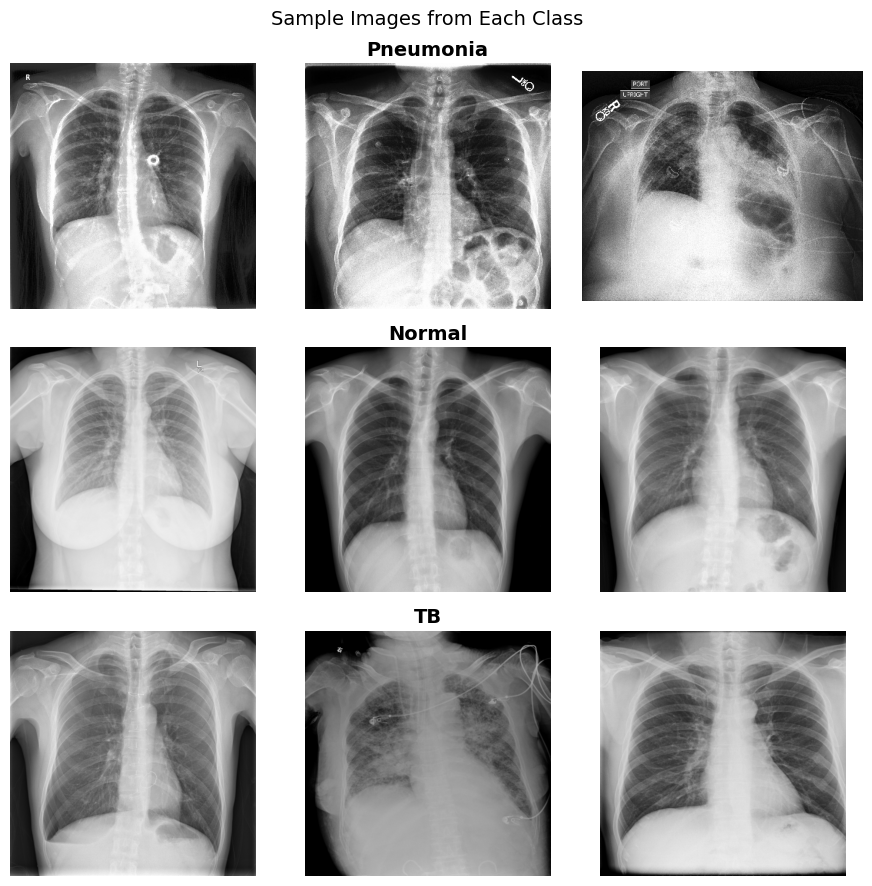

In [9]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def show_sample_images(chexpert_df, tbx11k_df, n_per_class=3):
    """
    Display sample images from each target class:
    - Pneumonia (from CheXpert)
    - Normal (from TBX11K)
    - TB (from TBX11K)

    Parameters
    ----------
    chexpert_df : pd.DataFrame
        CheXpert labels DataFrame with 'Path' and 'Class'.
    tbx11k_df : pd.DataFrame
        TBX11K labels DataFrame with 'Path' and 'Class'.
    n_per_class : int
        Number of images to display per class.
    """
    # Pick random samples per class (limit to available size)
    samples = {
        "Pneumonia": chexpert_df[chexpert_df["Class"] == "Pneumonia"].sample(
            min(len(chexpert_df[chexpert_df["Class"] == "Pneumonia"]), n_per_class)
        ),
        "Normal": tbx11k_df[tbx11k_df["Class"] == "Normal"].sample(
            min(len(tbx11k_df[tbx11k_df["Class"] == "Normal"]), n_per_class)
        ),
        "TB": tbx11k_df[tbx11k_df["Class"] == "TB"].sample(
            min(len(tbx11k_df[tbx11k_df["Class"] == "TB"]), n_per_class)
        ),
    }

    # Create grid of subplots. Add 3 images to each class for clear comparison.
    fig, axes = plt.subplots(len(samples), n_per_class, figsize=(n_per_class * 3, len(samples) * 3))

    for row, (cls, df) in enumerate(samples.items()):
        for col, (_, rec) in enumerate(df.iterrows()):
            if cls == "Pneumonia":
                # Prepend dataset root because Path is relative
                img_path = CHEXPERT_PATH / rec["Path"]
            else:  # Normal or TB from TBX11K
                img_path = TBX11K_PATH / "imgs" / rec["Path"]

            # Open and plot image.
            img = Image.open(img_path)
            axes[row, col].imshow(img, cmap="gray" if img.mode == "L" else None)
            axes[row, col].axis("off")
            if col == n_per_class // 2:
                axes[row, col].set_title(cls, fontsize=14, fontweight="bold")

    # Add title to the plot.
    plt.suptitle("Sample Images from Each Class", fontsize=14)
    plt.tight_layout()
    plt.show()

# Display 3 random samples per class (Pneumonia, Normal, and TB).
show_sample_images(chexpert_labels, tbx11k_df, n_per_class=3)

## 8. Compute Global Mean and Standard Deviation (CXR Dataset).
Compute the overall per-channel mean and standard deviation for the unified CXR dataset, combining CheXpert Pneumonia and TBX11K Normal/TB samples.
#### Rationale:
- Quantity the global brightness and contrast characteristics of the combined dataset to support reproducible preprocessing.
- Identify any systematic deviation between CXR intensity statistics and the default ImageNet normalisation commonly used in pretrained models.
- Provide dataset-specific statistics (CXR_MEAN, CXR_STD) for lightweight CNNs trained from scratch, while retaining ImageNet statistics for fair transfer-learning comparisons.
- Ensure both sets of parameters are available for downstream experiments, preserving consistency across the project.

In [10]:
# Compute global per-channel mean/std (CheXpert Pneumonia + TBX11K Normal/TB).

from PIL import Image
from torchvision import transforms as T
import torch, random

# Parameters (can be adjusted later).
IMG_SIZE = 256       # Match your training size.
N_CHEX, N_TBX = 2000, 2000
RNG_SEED = 42

# Build sample file lists (using EDA DataFrames).
chex_paths = [(CHEXPERT_PATH / p) for p in 
              chexpert_labels.loc[chexpert_labels["Class"] == "Pneumonia", "Path"].tolist()]
tbx_paths  = [(TBX11K_PATH / "imgs" / p) for p in tbx11k_df["Path"].tolist()]

random.seed(RNG_SEED)
random.shuffle(chex_paths)
random.shuffle(tbx_paths)
paths = chex_paths[:N_CHEX] + tbx_paths[:N_TBX]
print(f'Computing stats over {len(paths)} images: ')

# Minimal preprocessing (same geometry as training, no normalisation).
to_tensor = T.Compose([
    T.Resize(IMG_SIZE),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor()       # Converts [0–255] → [0–1], shape [C,H,W].
])

# Streaming accumulation for mean/std.
sum_c, sumsq_c = torch.zeros(3), torch.zeros(3)
for p in paths:
    try:
        x = to_tensor(Image.open(p).convert("RGB"))
        sum_c += x.mean(dim=(1,2))
        sumsq_c += x.std(dim=(1,2))
    except:
        continue

CXR_MEAN = (sum_c / len(paths)).tolist()
CXR_STD  = (sumsq_c / len(paths)).tolist()

# Report results and compare to ImageNet.
print(f'\nCXR_MEAN: {CXR_MEAN}')
print(f'CXR_STD : {CXR_STD}')

IMAGENET_MEAN, IMAGENET_STD = [0.485, 0.456, 0.406], [0.229, 0.224, 0.225]
delta_mean = [CXR_MEAN[i] - IMAGENET_MEAN[i] for i in range(3)]
delta_std  = [CXR_STD[i]  - IMAGENET_STD[i]  for i in range(3)]

print(f'\nmean (CXR - ImageNet): {delta_mean}')
print(f'std (CXR - ImageNet): {delta_std}')

Computing stats over 4000 images: 

CXR_MEAN: [0.5336471796035767, 0.5336471796035767, 0.5336471796035767]
CXR_STD : [0.26645559072494507, 0.26645559072494507, 0.26645559072494507]

mean (CXR - ImageNet): [0.048647179603576673, 0.07764717960357664, 0.12764717960357663]
std (CXR - ImageNet): [0.03745559072494506, 0.042455590724945064, 0.04145559072494506]


#### Insights:
- Greyscale images are converted to RGB, which duplicates the single intensity channel into three identical R, G and B channels. Identical R=G=B confirms proper grayscale to RGB conversion and no colour contamination.

- R = G = B ≈ 0.5336:
    - Brightness slightly above mid-gray, common for chest X-rays.
    - Identical channel values confirm that grayscale images were correctly converted to RGB.
- Std ≈ 0.266:
    - Indicates moderate contrast, consistent with well-exposed medical images.
    - Confirms that images are neither over- nor under-normalised.

- This values are expected:
    - Mid-gray dominance (air-filled lungs = dark, bones = bright --> average just above 0.5).
    - Moderate contrast: consistent and diagnostic quality.

- Normalising custom CNN with the CXR values aligns it with the true data distribution, optimal for training from scratch.
- This explains how and why the X-ray data differ from natuural photographs (IMAGENET), and therefore, it guides the choice of normalisation strategy for transfer learning vs. custom models.

## 9. Prepare EDA Artefacts for Persistance.
Build `source_pool_rel` (rel_path, Class, Source) from the existing `chexpert_labels` an `tbx11k_df`, and define the minimal config constants so the next save step succeeds.
#### Rationale:
- Keep paths relative and portable.
- Avoid re-runnig training logic in EDA (no loaders, no GPU).
- Stay reproducible with an explicit class index order.

In [11]:
# Rebuild minimal artefacts so the persist step can always run (idempotent; no training objects).

from pathlib import Path
import pandas as pd

# Resolve project roots used earlier.
PROJECT_ROOT = Path("..").resolve()                       # Step up from notebooks/ to repo root.
CHEXPERT_PATH = PROJECT_ROOT / "data" / "chexpert"        # CheXpert dataset root.
TBX11K_PATH   = PROJECT_ROOT / "data" / "tbx11k"          # TBX11K dataset root.

# 1) Ensure upstream EDA objects exist, or reconstruct them quickly from disk.
#    Guard against notebook execution order issues.
required_upstream = ["chexpert_labels", "tbx11k_df"]      # Objects expected from earlier EDA cells.
missing = [n for n in required_upstream if n not in globals()]

if "chexpert_labels" not in globals():
    chex_csv = CHEXPERT_PATH / "train.csv"
    if not chex_csv.exists():
        raise FileNotFoundError(f"Missing {chex_csv}")    # Fail fast with a clear message.
    chex_df = pd.read_csv(chex_csv)[["Path", "Pneumonia"]].copy()  # Load minimal columns needed.
    # Normalise CSV paths to local layout and filter to frontal views to match TBX11K orientation.
    chex_df["Path"] = chex_df["Path"].str.replace("CheXpert-v1.0-small/", "", regex=False)
    chex_df = chex_df[chex_df["Path"].str.contains("frontal")]
    # Map CheXpert label to study class; keep Non-Pneumonia for completeness (not used in the pool).
    chex_df["Class"] = chex_df["Pneumonia"].apply(lambda v: "Pneumonia" if v == 1 else "Non-Pneumonia")
    chexpert_labels = chex_df[["Path", "Class"]]          # Keep a tidy, small frame.

if "tbx11k_df" not in globals():
    list_file = TBX11K_PATH / "lists" / "all_trainval.txt"
    if not list_file.exists():
        raise FileNotFoundError(f"Missing {list_file}")   # Fail fast if split file is absent.
    paths = [p.strip() for p in list_file.read_text().splitlines() if p.strip()]  # Read relative paths.
    rows = []
    for p in paths:
        # Infer class from TBX11K conventions (folder prefix or filename suffix).
        cls = "TB" if p.startswith(("sick", "tb")) or p.endswith("_1.png") else "Normal"
        rows.append({"Path": p, "Class": cls})
    tbx11k_df = pd.DataFrame.from_records(rows)           # Build a compact labels table.

# 2) Build unified 3-class pool with RELATIVE paths (Pneumonia from CheXpert; TB/Normal from TBX11K).
chex = chexpert_labels[chexpert_labels["Class"] == "Pneumonia"].copy()  # Keep positives only.
chex.rename(columns={"Path": "rel_path"}, inplace=True)                 # Standardise column name.
chex["Source"] = "chexpert"                                             # Tag provenance.
chex["Class"] = "Pneumonia"                                             # Make label explicit and uniform.

tbx = tbx11k_df.copy()
tbx.rename(columns={"Path": "rel_path"}, inplace=True)                  # Standardise column name.
tbx["Source"] = "tbx11k"                                               # Tag provenance (Class already set).

# Concatenate into a single pool the training notebook will consume.
source_pool_rel = pd.concat(
    [chex[["rel_path", "Class", "Source"]], tbx[["rel_path", "Class", "Source"]]],
    ignore_index=True
)

# 3) Define fixed label order + preprocessing constants used downstream (keeps experiments reproducible).
CLASS_TO_INDEX = {"Pneumonia": 0, "TB": 1, "Normal": 2}   # Stable mapping for loaders/metrics.
IMG_SIZE = 256                                            # Baseline input size for all models.
IMAGENET_MEAN = [0.485, 0.456, 0.406]                     # Normalisation: mean (ImageNet).
IMAGENET_STD  = [0.229, 0.224, 0.225]                     # Normalisation: std (ImageNet).

# 4) Provide a harmless placeholder so the persist cell’s existence check passes (avoid loader instantiation in EDA).
train_dataset = None

# 5) Confirm counts in the required order (quick sanity check before persisting).
counts = source_pool_rel["Class"].value_counts()
print("Ready to persist. Class counts:",
      {"Pneumonia": int(counts.get("Pneumonia", 0)),
       "TB": int(counts.get("TB", 0)),
       "Normal": int(counts.get("Normal", 0))})

Ready to persist. Class counts: {'Pneumonia': 4675, 'TB': 4798, 'Normal': 4178}


## 10. Duplicate-Aware Train/Val/Test Split.
This section rebuilds the dataset splits using a perceptual-hash deduplication pipeline.
The goal is to ensure that no image appears in more than one split, even if filenames differ or images have been resized.
This prevents accuracy inflation caused by hidden duplicates, which is common in medical-image datasets.
#### Rationale:
- Detects duplicates based on pixel content rather than file names.
- Ensures that train, validation, and test splits are mutually exclusive.
- Removes intra-dataset duplicates before any splitting occurs.
- Produces stratified splits that preserve class balance.
- Guarantees a clean evaluation protocol with no leakage between partitions.
- Saves `train/val/test` CSV files for reproducible downstream loading.

In [12]:
# 10. Duplicate-Aware Train/Val/Test Split (replaces previous split).
# This block builds a deduplicated dataset pool and produces clean
# stratified train, validation, and test splits. Perceptual hashing
# ensures that image duplicates are detected by content rather than
# filename, avoiding inflated accuracy caused by leakage.


import hashlib
from PIL import Image
from sklearn.model_selection import train_test_split


def hash_image_abs(abs_path):
    """
    Compute a deterministic SHA-256 hash based on a grayscale,
    downsampled version of the image.

    The downsampling (64×64) and grayscale conversion provide
    a stable representation for duplicate detection while being
    computationally efficient.

    Args:
        abs_path (str): Full absolute path to an image file.

    Returns:
        str: SHA-256 hash string.
    """
    img = Image.open(abs_path).convert("L") # Convert to grayscale for stability across sources.
    img = img.resize((64, 64)) # Resize to fixed resolution for consistent hashing.
    return hashlib.sha256(img.tobytes()).hexdigest() # Hash raw bytes to obtain a unique signature.


# 1. Build absolute-path column for hashing.
abs_paths = []  # Temporary list to store full image paths.

for i, row in source_pool_rel.iterrows(): # Iterate over each row in the unified source pool.
    if row["Source"] == "chexpert": # For CheXpert-origin images:
        abs_p = CHEXPERT_PATH / row["rel_path"] # Restore original absolute path.
    else: # For TBX11K-origin images:
        abs_p = TBX11K_PATH / "imgs" / row["rel_path"] # TBX images live inside the 'imgs' folder.
    abs_paths.append(str(abs_p)) # Store the absolute path as string.

source_pool_rel["abs_path"] = abs_paths # Add absolute paths to the dataframe.


# 2. Compute perceptual hashes for all images.
print("Hashing all images...")

hashes = []  # List to store hashes.

for p in source_pool_rel["abs_path"]: # Loop through every absolute path.
    try:
        hashes.append(hash_image_abs(p)) # Compute SHA-256 perceptual hash.
    except Exception: # If reading fails (rare), record missing hash.
        hashes.append(None)

source_pool_rel["hash"] = hashes # Attach hash column to dataframe.

# Remove rows where hashing failed (e.g., unreadable file).
source_pool_rel = source_pool_rel.dropna(subset=["hash"]).reset_index(drop=True)


# 3. Remove internal duplicates BEFORE splitting.
before = len(source_pool_rel) # Record number of rows before deduplication.

source_pool_rel = source_pool_rel.drop_duplicates(
    subset=["hash"] # Keep only unique perceptual hashes.
).reset_index(drop=True)

after = len(source_pool_rel) # Record number of rows after deduplication.

print(f"Removed {before - after} internal duplicates inside the pool.")


# 4. Perform clean stratified train/val/test split.
# Split off 20% of the data as temp_df (val + test), preserving class proportions.
train_df, temp_df = train_test_split(
    source_pool_rel,
    test_size=0.20, # 80% train, 20% temporary.
    stratify=source_pool_rel["Class"], # Maintain class distribution.
    random_state=42 # Reproducibility.
)

# Split the temporary subset into 50% validation and 50% test.
val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50, # Half of the 20% --> 10% val, 10% test.
    stratify=temp_df["Class"], # Maintain class distribution.
    random_state=42
)

print(f"Train: {len(train_df)} images")
print(f"Val  : {len(val_df)} images")
print(f"Test : {len(test_df)} images")


# 5. Save clean splits to experiments/pools/
out_dir = PROJECT_ROOT / "experiments" / "pools" # Output directory for split CSVs.
out_dir.mkdir(parents=True, exist_ok=True) # Ensure directory exists.

train_df.to_csv(out_dir / "train_split.csv", index=False) # Write train split.
val_df.to_csv(out_dir / "val_split.csv", index=False) # Write validation split.
test_df.to_csv(out_dir / "test_split.csv", index=False) # Write test split.

print("Saved:")
print(" - train_split.csv")
print(" - val_split.csv")
print(" - test_split.csv")

# 6. Remove temporary columns from in-memory dataset
# These columns are only needed for hashing; they should not persist.
source_pool_rel = source_pool_rel.drop(columns=["abs_path", "hash"])

Hashing all images...
Removed 130 internal duplicates inside the pool.
Train: 10816 images
Val  : 1352 images
Test : 1353 images
Saved:
 - train_split.csv
 - val_split.csv
 - test_split.csv


## 11. Persist EDA Outputs (for 02_training_baseline.ipynb).
Save the unified pool (`source_pool_rel`) and tiny preprocessing config (size, ImageNet, stats, transform mode).
#### Rationale:
- Reproduce training without rerunning EDA.
- Keep paths portable (relative)
- Make setup auditable under `experiments/pools/`.
- Fail fast if required objects are missing.

In [13]:
# Persist EDA outputs for reuse in 02_training_baseline.ipynb (single, tidy cell).

from pathlib import Path
import json

# Ensure the notebook actually produced the objects planned to be saved (fail fast = clearer debugging).
required = ["source_pool_rel", "CLASS_TO_INDEX", "IMG_SIZE", "IMAGENET_MEAN", "IMAGENET_STD", "train_dataset"]
for name in required:
    if name not in globals():
        raise RuntimeError(f"Missing `{name}`: run the prior cells first.")

# Resolve project root (this notebook lives in notebooks/, so ".." is the repo root).
PROJECT_ROOT = Path("..").resolve()

# Create a canonical place for reusable pools/config snapshots.
out_dir = PROJECT_ROOT / "experiments" / "pools"
out_dir.mkdir(parents=True, exist_ok=True)

# 1. Save the unified pool (relative paths + labels + source).
pool_csv = out_dir / "source_pool_rel.csv"
source_pool_rel.to_csv(pool_csv, index=False)

# 2. Save a minimal preprocessing/config snapshot so training can rebuild transforms identically.
#    Set transform_mode to "letterbox" if you switched to aspect-preserving padding; otherwise "center-crop".
cfg = {
    "class_to_index": CLASS_TO_INDEX,   # {'Pneumonia': 0, 'TB': 1, 'Normal': 2}
    "img_size": int(IMG_SIZE),          # 256 baseline (or 320 if you switch later)
    "imagenet_mean": IMAGENET_MEAN,     # [0.485, 0.456, 0.406]
    "imagenet_std": IMAGENET_STD,       # [0.229, 0.224, 0.225]
    "cxr_mean": CXR_MEAN,               # dataset-specific stats (computed in section 8a)
    "cxr_std": CXR_STD,                 # dataset-specific stats (computed in section 8a)
    "transform_mode": "letterbox"       # change to "center-crop" if that is your current pipeline
}

cfg_path = out_dir / "preprocessing_config.json"
cfg_path.write_text(json.dumps(cfg, indent=2))

print("Saved:")
print(" -", pool_csv.relative_to(PROJECT_ROOT))
print(" -", cfg_path.relative_to(PROJECT_ROOT))

Saved:
 - experiments/pools/source_pool_rel.csv
 - experiments/pools/preprocessing_config.json


#### Insights:
- The configuration now includes both **ImageNet** and **CXR** statistics, allowing fair **transfer-learning comparison** and **dataset-specific normalisation**.